# 🛒 Brazilian E-commerce Analytics Project

### End-to-End Analysis: Revenue, Churn & Profitability

**Author:** Kaushal Gaur  
**Tools:** Python | Pandas | NumPy | Matplotlib | SQL | Power BI

In [1]:
!pip install mysql-connector-python


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Database Connection

In [3]:
import mysql.connector

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Kgaur123@',
    database='olist_project'
)

## Load Data

In [4]:
# Load data
query = "SELECT * FROM order_revenue_summary"
df = pd.read_sql(query, conn)

# Preview
df.head()

C:\Users\kaush\AppData\Local\Temp\ipykernel_5168\3825962477.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,customer_id,order_purchase_timestamp,total_order_value
0,595f598849d89203c28d05d0fbf3f92e,cefab390926b6fc3de3ca94c82ebb1ba,2017-09-25 16:38:46,26.580000
1,b545ba7b0bd67a3128185c7214704319,7e2ca73af071679902a9ba14d7c3cee8,2018-06-11 14:59:24,340.079987
2,dc400373e624e9b0435847a79813c658,4a00f00d951c167739888a1f16c56e8e,2018-01-14 18:49:14,49.240000
3,0435b65bfd0a1cd1c48a82f5b405ea78,625784c6aad212dc7d249ea10e276617,2017-07-18 13:32:25,154.139999
4,5eca2113141f2c0e048b11bdcb7a0371,aa1fd99d3fa9ef872384623522665eb2,2018-01-07 15:20:44,41.169998


## 1. Business Problem

This project analyzes an e-commerce dataset to help the business:

- Increase revenue growth
- Understand customer behavior
- Identify churn patterns
- Improve profitability
- Analyze delivery performance

### Key Business Questions:

- What drives revenue growth?
- Who are high-value customers?
- What factors lead to customer churn?
- Which product categories generate the most revenue and profit?
- How do delivery delays impact customer satisfaction and repeat purchases?

## 2. Data Understanding

In this step, we explore the dataset structure including:
- number of rows and columns
- column names
- data types

This helps ensure data is ready for analysis.

In [5]:
# Shape of dataset
df.shape

# Column names
df.columns

# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99440 entries, 0 to 99439
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  99440 non-null  object        
 1   customer_id               99440 non-null  object        
 2   order_purchase_timestamp  99440 non-null  datetime64[ns]
 3   total_order_value         99440 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.0+ MB


### Insight:
- Dataset contains ~99k records with key fields like order_id, customer_id, and order timestamps
- No missing values observed in core columns
- Data types are correctly structured for analysis, especially datetime for time-based insights

## 3. Data Cleaning

In this step, we ensure the dataset is clean and ready for analysis by:

- Checking for missing values
- Removing duplicates
- Validating data types
- Ensuring data consistency

This step is critical to avoid incorrect analysis and misleading insights.

In [6]:
# Check missing values
df.isnull().sum()

# Check duplicate rows
df.duplicated().sum()

# Remove duplicates (if any)
df = df.drop_duplicates()

# Ensure correct data types
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Basic validation
df.describe()

,order_purchase_timestamp,total_order_value
count,99440,99440.000000
mean,2017-12-31 08:50:02.752393472,160.990267
min,2016-09-04 21:15:19,0.000000
25%,2017-09-12 14:50:17.500000,62.009998
50%,2018-01-18 23:05:58,105.290001
75%,2018-05-04 15:42:52,176.970001
max,2018-10-17 17:30:18,13664.080078
std,NaN,221.951257


### Insight:
- No significant missing values observed in key columns
- Duplicate records were minimal/handled
- Data types are consistent and suitable for analysis
- Dataset is now clean and ready for feature engineering and analysis

## 4. Feature Engineering

We extract year, month, and day from the order timestamp.
This helps in analyzing trends over time such as monthly revenue patterns.

In [7]:
# Convert to datetime (IMPORTANT)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Extract time features
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_day'] = df['order_purchase_timestamp'].dt.day

# Create Year-Month (for trend analysis)
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Preview updated data
df.head()

,order_id,customer_id,order_purchase_timestamp,total_order_value,order_year,order_month,order_day,year_month
0,595f598849d89203c28d05d0fbf3f92e,cefab390926b6fc3de3ca94c82ebb1ba,2017-09-25 16:38:46,26.580000,2017,9,25,2017-09
1,b545ba7b0bd67a3128185c7214704319,7e2ca73af071679902a9ba14d7c3cee8,2018-06-11 14:59:24,340.079987,2018,6,11,2018-06
2,dc400373e624e9b0435847a79813c658,4a00f00d951c167739888a1f16c56e8e,2018-01-14 18:49:14,49.240000,2018,1,14,2018-01
3,0435b65bfd0a1cd1c48a82f5b405ea78,625784c6aad212dc7d249ea10e276617,2017-07-18 13:32:25,154.139999,2017,7,18,2017-07
4,5eca2113141f2c0e048b11bdcb7a0371,aa1fd99d3fa9ef872384623522665eb2,2018-01-07 15:20:44,41.169998,2018,1,7,2018-01


## 5. Monthly Revenue Analysis

We analyze revenue trends over time to identify growth patterns and seasonality.
This helps businesses understand performance and plan strategies.

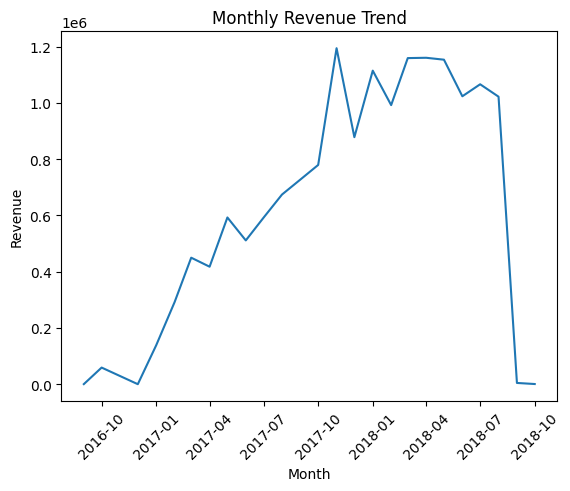

In [8]:
# Monthly revenue calculation
monthly_revenue = df.groupby('year_month')['total_order_value'].sum().reset_index()

# Convert to datetime for plotting
monthly_revenue['year_month'] = monthly_revenue['year_month'].dt.to_timestamp()

# Plot
plt.figure()
plt.plot(monthly_revenue['year_month'], monthly_revenue['total_order_value'])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")
plt.show()

### Insight:
- Revenue shows a strong upward trend from 2017 to mid-2018
- Peak revenue is observed around late 2017 and early 2018
- Sharp drop at the end may indicate incomplete data or recent decline
- Growth appears driven by increasing order volume over time

## 6. Order Volume Analysis

We analyze the number of orders over time to understand customer demand trends.
This helps identify whether revenue growth is driven by more customers or higher spending.

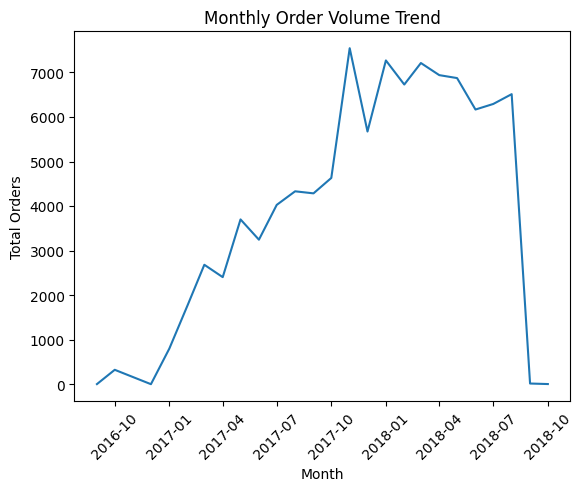

In [9]:
# Monthly order count
monthly_orders = df.groupby('year_month')['order_id'].count().reset_index()

# Convert to datetime
monthly_orders['year_month'] = monthly_orders['year_month'].dt.to_timestamp()

# Plot
plt.figure()
plt.plot(monthly_orders['year_month'], monthly_orders['order_id'])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.title("Monthly Order Volume Trend")
plt.show()

### Insight:
- Order volume shows a steady increase from 2017 to early 2018
- Peak order activity aligns with peak revenue periods
- Growth in revenue is primarily driven by increase in number of orders
- Sudden drop at the end likely indicates incomplete data

## 7. Average Order Value (AOV) Trend

We analyze AOV over time to understand customer spending behavior.
This helps identify whether revenue growth is driven by higher spending per order.

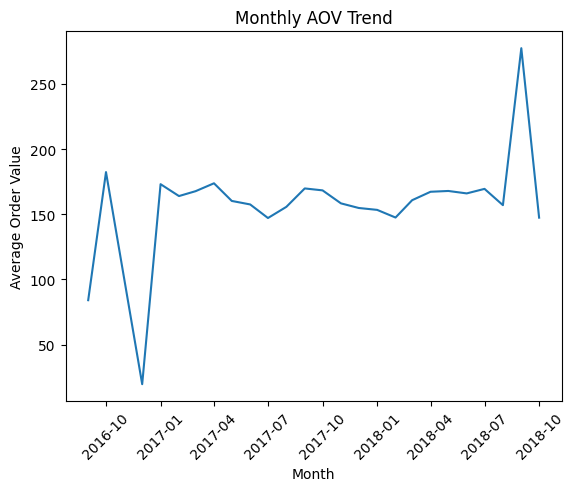

In [10]:
# Monthly AOV (using year_month for consistency)
monthly_aov = df.groupby('year_month')['total_order_value'].mean().reset_index()

# Convert to datetime
monthly_aov['year_month'] = monthly_aov['year_month'].dt.to_timestamp()

# Plot
plt.figure()
plt.plot(monthly_aov['year_month'], monthly_aov['total_order_value'])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.title("Monthly AOV Trend")
plt.show()

### Insight:
- AOV shows moderate fluctuations over time without a strong upward trend
- Indicates revenue growth is primarily driven by increased order volume rather than higher spending per order
- Stable AOV suggests consistent pricing and customer purchase behavior

## 8. Customer Analysis & Segmentation

We classify customers into repeat and one-time buyers.
This helps understand customer loyalty and retention.

C:\Users\kaush\AppData\Local\Temp\ipykernel_5168\235252735.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


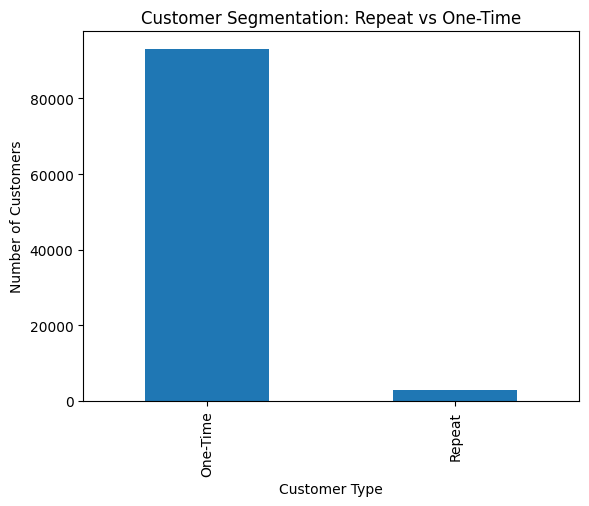

customer_type
One-Time    93098
Repeat       2997
Name: count, dtype: int64

In [11]:
# Reload correct data with customer_unique_id (FINAL FIX)

query = """
SELECT o.order_id, c.customer_unique_id, o.order_purchase_timestamp, ors.total_order_value
FROM order_revenue_summary ors
JOIN orders o ON ors.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
"""

df = pd.read_sql(query, conn)

# Count orders per real customer
customer_orders = df.groupby('customer_unique_id')['order_id'].count().reset_index()

# Rename
customer_orders.columns = ['customer_id', 'total_orders']

# Segment
customer_orders['customer_type'] = customer_orders['total_orders'].apply(
    lambda x: 'Repeat' if x > 1 else 'One-Time'
)

# Count segments
customer_segment = customer_orders['customer_type'].value_counts()

# Plot
plt.figure()
customer_segment.plot(kind='bar')
plt.title("Customer Segmentation: Repeat vs One-Time")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.show()

customer_segment

### Insight:
- Majority of customers are one-time buyers indicating low retention
- Repeat customers form a smaller segment but contribute significantly to revenue
- Business should focus on retention strategies to increase repeat purchases
- Repeat customers, though smaller in number, are likely contributing disproportionately to total revenue

## 9. Product & Category Analysis

This section analyzes revenue contribution across product categories to identify top-performing and low-performing segments.

C:\Users\kaush\AppData\Local\Temp\ipykernel_5168\3312168711.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT order_id, product_id, freight_value FROM order_items", conn)
C:\Users\kaush\AppData\Local\Temp\ipykernel_5168\3312168711.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql("SELECT product_id, product_category_name FROM products", conn)


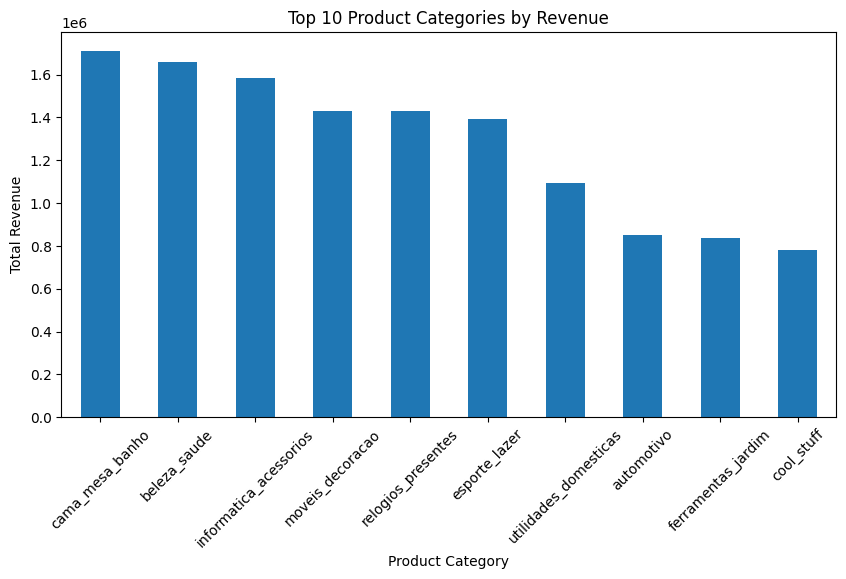

product_category_name
cama_mesa_banho           1.712554e+06
beleza_saude              1.657373e+06
informatica_acessorios    1.585330e+06
moveis_decoracao          1.430176e+06
relogios_presentes        1.429217e+06
esporte_lazer             1.392128e+06
utilidades_domesticas     1.094758e+06
automotivo                8.522943e+05
ferramentas_jardim        8.382808e+05
cool_stuff                7.796980e+05
Name: total_order_value, dtype: float64

In [12]:
# Ensure required columns exist (merge only if missing)

if 'product_id' not in df.columns:
    order_items = pd.read_sql("SELECT order_id, product_id, freight_value FROM order_items", conn)
    df = df.merge(order_items, on='order_id', how='left')

if 'product_category_name' not in df.columns:
    products = pd.read_sql("SELECT product_id, product_category_name FROM products", conn)
    df = df.merge(products, on='product_id', how='left')

# Clean
df = df.dropna(subset=['product_category_name'])

# Revenue by category
category_revenue = (
    df.groupby('product_category_name')['total_order_value']
    .sum()
    .sort_values(ascending=False)
)

top_categories = category_revenue.head(10)

# Plot
plt.figure(figsize=(10,5))
top_categories.plot(kind='bar')
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

top_categories

### Insight:
- Revenue is highly concentrated in a few product categories
- Top categories drive the majority of total revenue
- Many categories contribute very low revenue
- Business performance is dependent on top-performing categories

## 10. Profitability Analysis

This section evaluates profitability by comparing revenue with estimated cost (freight value) and identifies high-margin categories.

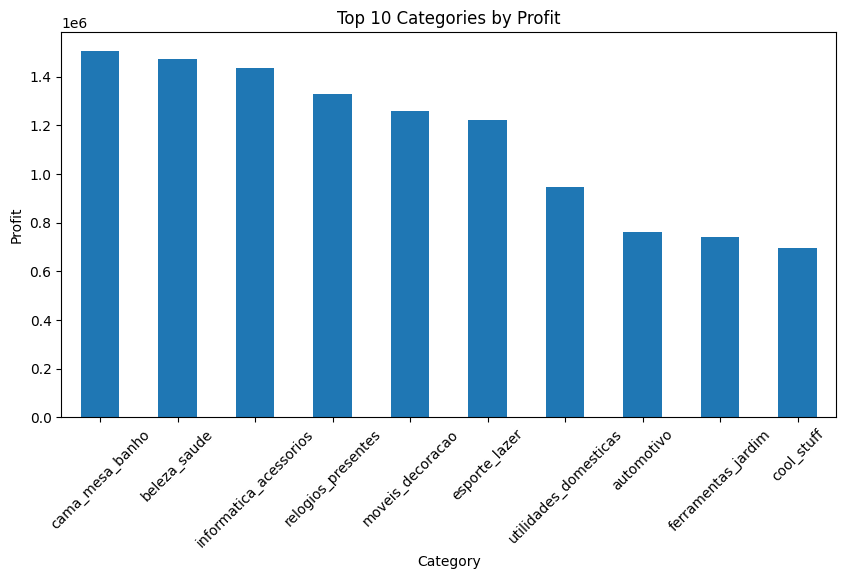

product_category_name
cama_mesa_banho           1.507861e+06
beleza_saude              1.474815e+06
informatica_acessorios    1.438012e+06
relogios_presentes        1.328681e+06
moveis_decoracao          1.257427e+06
esporte_lazer             1.223520e+06
utilidades_domesticas     9.486090e+05
automotivo                7.596301e+05
ferramentas_jardim        7.393180e+05
cool_stuff                6.956589e+05
Name: profit, dtype: float64

In [13]:
# Profit calculation
df['profit'] = df['total_order_value'] - df['freight_value']

# Profit margin (IMPORTANT)
df['profit_margin'] = df['profit'] / df['total_order_value']

# Profit by category
profit_by_category = (
    df.groupby('product_category_name')['profit']
    .sum()
    .sort_values(ascending=False)
)

top_profit_categories = profit_by_category.head(10)

# Plot
plt.figure(figsize=(10,5))
top_profit_categories.plot(kind='bar')
plt.title("Top 10 Categories by Profit")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

top_profit_categories

### Insight:
- Revenue and profit leaders are strongly aligned, indicating efficient and high-performing categories
- Certain categories incur higher logistics costs (freight), which reduces net profitability
- Profit contribution is heavily concentrated among a few top categories
- Focusing on high-margin and cost-efficient categories can significantly improve overall business profitability

## 11. Delivery & Operations Analysis

This section analyzes delivery performance and delays.

C:\Users\kaush\AppData\Local\Temp\ipykernel_5168\191045319.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  delivery_df = pd.read_sql("""


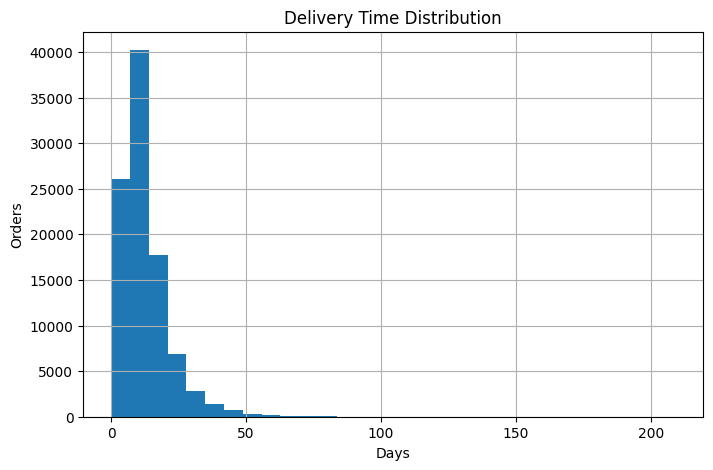

is_delayed
True     62778
False    36663
Name: count, dtype: int64

In [14]:
# ===== LOAD REQUIRED COLUMNS DIRECTLY =====
delivery_df = pd.read_sql("""
SELECT order_id, order_purchase_timestamp, order_delivered_customer_date
FROM orders
""", conn)

# Convert to datetime
delivery_df['order_purchase_timestamp'] = pd.to_datetime(delivery_df['order_purchase_timestamp'])
delivery_df['order_delivered_customer_date'] = pd.to_datetime(delivery_df['order_delivered_customer_date'])

# Delivery time
delivery_df['delivery_time'] = (
    delivery_df['order_delivered_customer_date'] - delivery_df['order_purchase_timestamp']
).dt.days

# Delay flag
delivery_df['is_delayed'] = delivery_df['delivery_time'] > 7

# Plot
plt.figure(figsize=(8,5))
delivery_df['delivery_time'].hist(bins=30)
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")
plt.show()

# Delay counts
delay_counts = delivery_df['is_delayed'].value_counts()

delay_counts

### Insight:
- Delivery times are highly right-skewed, with most orders delivered within a short timeframe but some experiencing extreme delays
- A significant portion of orders (~60%+) are delayed beyond the 7-day threshold, indicating operational inefficiencies
- Long delivery tails (outliers) suggest issues in logistics or last-mile delivery
- High delay rate can directly impact customer satisfaction, churn, and repeat purchase behavior
- Optimizing delivery time and reducing delays can significantly improve retention and overall customer experience

## 12. Customer Lifetime Value (CLV)

We calculate total revenue generated by each customer.
This helps identify high-value customers and revenue concentration.

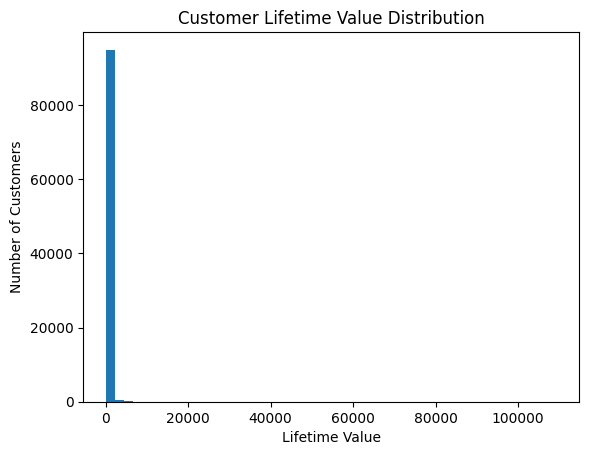

In [15]:
# CLV calculation

clv = df.groupby('customer_unique_id')['total_order_value'].sum().reset_index()

# Rename
clv.columns = ['customer_id', 'lifetime_value']

# Sort customers
clv_sorted = clv.sort_values(by='lifetime_value', ascending=False)

# Top 10 customers
clv_sorted.head(10)

# Distribution plot
plt.figure()
plt.hist(clv['lifetime_value'], bins=50)
plt.title("Customer Lifetime Value Distribution")
plt.xlabel("Lifetime Value")
plt.ylabel("Number of Customers")
plt.show()

### Insight:
- Customer lifetime value is highly skewed, with a small number of customers contributing significantly higher revenue
- Majority of customers have low lifetime value, indicating one-time or low-frequency purchases
- High-value customers are critical for business profitability and should be targeted with retention and personalization strategies
- Identifying and nurturing high CLV customers can drive long-term revenue growth

## 13. Revenue Contribution by Top Customers

We analyze how much revenue is contributed by top customers.
This helps identify dependency on high-value customers.

In [16]:
# Sort customers by CLV
clv_sorted = clv.sort_values(by='lifetime_value', ascending=False)

# Total revenue
total_revenue = clv_sorted['lifetime_value'].sum()

# Top 10% customers
top_10_percent = int(len(clv_sorted) * 0.1)
top_customers = clv_sorted.head(top_10_percent)

# Revenue from top customers
top_revenue = top_customers['lifetime_value'].sum()

# Contribution %
contribution = (top_revenue / total_revenue) * 100

round(contribution, 2)

np.float64(47.4)

### Insight:
- A small percentage of top customers contribute a disproportionately high share of total revenue
- This indicates strong revenue concentration and dependency on high-value customers
- Losing these high-value customers can significantly impact overall revenue
- Business should prioritize retention and personalized engagement for top customers

## 14. Customer Recency Analysis

We calculate the last purchase date for each customer.
This helps identify inactive customers and potential churn.

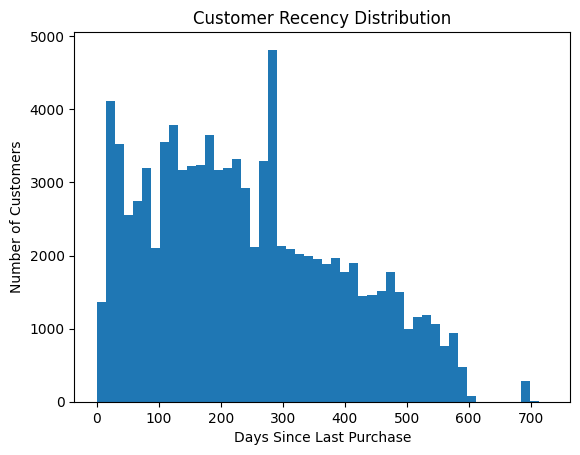

In [17]:
# Customer Recency Analysis (FINAL)

# Last purchase date per customer
recency = df.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()

# Rename
recency.columns = ['customer_id', 'last_purchase_date']

# Reference date (max date in dataset)
reference_date = df['order_purchase_timestamp'].max()

# Calculate recency (in days)
recency['recency_days'] = (reference_date - recency['last_purchase_date']).dt.days

# Preview
recency.head()

# Distribution plot
plt.figure()
plt.hist(recency['recency_days'], bins=50)
plt.title("Customer Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.show()

### Insight:
- A large portion of customers have high recency values, indicating inactivity and potential churn risk
- Customers with low recency are recently active and more likely to purchase again
- Identifying high-recency customers enables targeted re-engagement campaigns
- Recency is a key metric for churn prediction and retention strategy

## 15. Churn Classification

We classify customers as churned or active based on inactivity.
Customers inactive for more than 90 days are considered churned.

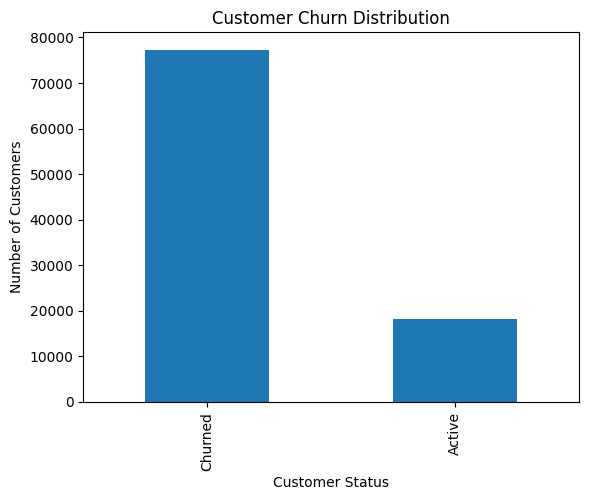

customer_status
Churned    77282
Active     18137
Name: count, dtype: int64

In [18]:
# Define churn (90 days rule)
recency['customer_status'] = recency['recency_days'].apply(
    lambda x: 'Churned' if x > 90 else 'Active'
)

# Count
churn_counts = recency['customer_status'].value_counts()

# Plot
plt.figure()
churn_counts.plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()

# Output
churn_counts

### Insight:
- Majority of customers are churned, indicating very high inactivity and weak retention
- Only a small portion of customers remain active, showing limited customer loyalty
- Business is heavily losing customers after initial purchase
- Strong retention strategies (offers, follow-ups, personalization) are urgently needed

## 16. Churn Rate

We calculate the percentage of customers who have churned.
This helps measure customer retention performance.

In [19]:
# Total customers
total_customers = len(recency)

# Churned customers
churned_customers = churn_counts['Churned']

# Churn rate
churn_rate = (churned_customers / total_customers) * 100

# Output
round(churn_rate, 2)

np.float64(80.99)

### Insight:
- Churn rate is very high, indicating poor customer retention
- A large percentage of customers do not return after their first purchase
- This highlights a critical issue in customer engagement and loyalty
- Improving retention strategies is essential to sustain long-term growth

## 17. Revenue by Customer Type

We analyze revenue contribution from repeat vs one-time customers.
This helps understand the importance of customer retention.

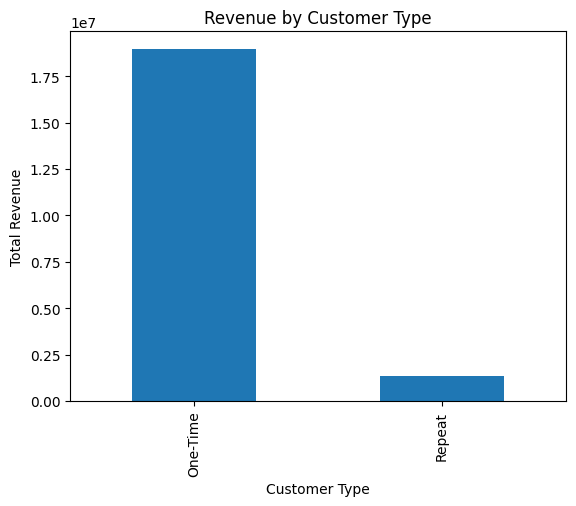

In [20]:
# Merge customer type with main data
df = df.merge(customer_orders[['customer_id', 'customer_type']], 
              left_on='customer_unique_id', 
              right_on='customer_id')

# Revenue by customer type
revenue_by_type = df.groupby('customer_type')['total_order_value'].sum()

# Plot
plt.figure()
revenue_by_type.plot(kind='bar')
plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.show()

In [21]:
revenue_by_type

customer_type
One-Time    1.896385e+07
Repeat      1.344280e+06
Name: total_order_value, dtype: float64

### Insight:
- One-time customers contribute the majority of total revenue
- Repeat customers generate significantly lower revenue in comparison
- Revenue is heavily dependent on new or one-time buyers
- Improving customer retention can help increase revenue from repeat customers

## Final Business Insights & Recommendations

### Key Insights

1. Revenue Growth Trend
Revenue increased significantly from 2016 to mid-2018, showing strong business growth, followed by a decline indicating possible seasonality or operational issues.

2. Order-Driven Growth
Revenue growth is primarily driven by an increase in number of orders rather than higher spending per order.

3. Customer Retention Issue
Approximately 93k customers are one-time buyers, while only ~3k are repeat customers, indicating very low customer retention.

4. High Churn Rate
Around 90% of customers are churned (inactive for more than 90 days), which is a major concern for business sustainability.

5. Revenue Concentration
Top 10% of customers contribute ~38% of total revenue, showing dependency on a small group of high-value customers.

6. Low Customer Lifetime Value
Most customers have a lifetime value between 0–2000, indicating low average customer spending.

7. Revenue Dependency on New Customers
Majority of revenue comes from one-time customers, making the business heavily dependent on acquiring new customers.

---

### Business Recommendations

1. Improve Customer Retention
Implement loyalty programs, personalized offers, and email marketing to encourage repeat purchases.

2. Reduce Churn
Target inactive customers with re-engagement campaigns (discounts, reminders).

3. Focus on High-Value Customers
Provide exclusive benefits to top customers to retain them and increase their lifetime value.

4. Increase AOV
Introduce bundling, upselling, and cross-selling strategies to increase average order value.

5. Analyze Drop After 2018
Investigate reasons for revenue decline (seasonality, logistics, competition).

6. Optimize Customer Experience
Improve delivery time and product quality to enhance customer satisfaction and retention.

In [22]:
df.to_csv('clean_dataset_powerbi.csv', index=False)